# ✈️ Flight Price — Data Cleaning & KPI Analysis**Objective:** Clean a real-world flight booking dataset and answer 7 business KPIs about pricing, routes, stops, airlines, and departure timing.**Dataset:** 10,683 domestic flight listings, 11 raw columns (airline, route, times, duration, stops, price)**Tools:** Python · Pandas · Matplotlib · Seaborn**Workflow:** Data Loading → Missing Value Cleaning → Ad-hoc Filtering → Feature Engineering (dates, times, duration) → 7 KPI Analysis---

## 1. Setup & Data Loading

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
!git clone 'https://github.com/mdooo7/DA-Flight-Price-Project'

## 2. Initial Data Overview

In [ ]:
df = pd.read_excel('/content/DA-Flight-Price-Project/data/flight_price.xlsx')
df

In [ ]:
df.shape

(10683, 11)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10683 entries, 0 to 10682
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Airline          10683 non-null  object
 1   Date_of_Journey  10683 non-null  object
 2   Source           10683 non-null  object
 3   Destination      10683 non-null  object
 4   Route            10682 non-null  object
 5   Dep_Time         10683 non-null  object
 6   Arrival_Time     10683 non-null  object
 7   Duration         10683 non-null  object
 8   Total_Stops      10682 non-null  object
 9   Additional_Info  10683 non-null  object
 10  Price            10683 non-null  int64 
dtypes: int64(1), object(10)
memory usage: 918.2+ KB


In [ ]:
df.describe()

,Price
count,10683.000000
mean,9087.064121
std,4611.359167
min,1759.000000
25%,5277.000000
50%,8372.000000
75%,12373.000000
max,79512.000000


**Snapshot:** 10,683 flight listings, 11 columns. Price ranges from **₹1,759 to ₹79,512** (average **₹9,087**). `Date_of_Journey`, `Dep_Time`, `Arrival_Time`, and `Duration` are all stored as text and will need parsing before analysis.

## 3. Data Cleaning — Missing Values

In [ ]:
df.isnull().sum()

,0
Airline,0
Date_of_Journey,0
Source,0
Destination,0
Route,1
Dep_Time,0
Arrival_Time,0
Duration,0
Total_Stops,1
Additional_Info,0


Only 2 missing values total, across `Route` and `Total_Stops` — a small enough gap to simply drop.

In [ ]:
df.dropna(inplace=True)

In [ ]:
df.isnull().sum()

,0
Airline,0
Date_of_Journey,0
Source,0
Destination,0
Route,0
Dep_Time,0
Arrival_Time,0
Duration,0
Total_Stops,0
Additional_Info,0


**Result:** 1 row dropped (both missing values were in the same row) — 10,682 rows remain.

## 4. Ad-hoc Business Filters

In [ ]:
df[df['Airline'] == "IndiGo"]

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302
11,IndiGo,18/04/2019,Kolkata,Banglore,CCU → BLR,20:20,22:55,2h 35m,non-stop,No info,4174
14,IndiGo,24/04/2019,Kolkata,Banglore,CCU → BLR,17:15,19:50,2h 35m,non-stop,No info,4804
...,...,...,...,...,...,...,...,...,...,...,...
10631,IndiGo,15/05/2019,Delhi,Cochin,DEL → BLR → COK,02:00,07:45,5h 45m,1 stop,No info,6037
10641,IndiGo,6/03/2019,Chennai,Kolkata,MAA → CCU,07:55,10:15,2h 20m,non-stop,No info,7295
10649,IndiGo,1/03/2019,Kolkata,Banglore,CCU → BLR,21:25,00:05 02 Mar,2h 40m,non-stop,No info,4778
10664,IndiGo,9/04/2019,Banglore,Delhi,BLR → DEL,18:55,21:50,2h 55m,non-stop,No info,4823


In [ ]:
df[df['Destination'] == 'New Delhi']

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302
6,Jet Airways,12/03/2019,Banglore,New Delhi,BLR → BOM → DEL,18:55,10:25 13 Mar,15h 30m,1 stop,In-flight meal not included,11087
7,Jet Airways,01/03/2019,Banglore,New Delhi,BLR → BOM → DEL,08:00,05:05 02 Mar,21h 5m,1 stop,No info,22270
8,Jet Airways,12/03/2019,Banglore,New Delhi,BLR → BOM → DEL,08:55,10:25 13 Mar,25h 30m,1 stop,In-flight meal not included,11087
...,...,...,...,...,...,...,...,...,...,...,...
10638,Jet Airways,21/03/2019,Banglore,New Delhi,BLR → BOM → DEL,21:25,11:25 19 Mar,14h,1 stop,In-flight meal not included,7832
10660,Vistara,21/03/2019,Banglore,New Delhi,BLR → DEL,21:10,00:05 19 Mar,2h 55m,non-stop,No info,4878
10667,Jet Airways,12/03/2019,Banglore,New Delhi,BLR → BOM → DEL,22:55,20:20 13 Mar,21h 25m,1 stop,In-flight meal not included,11087
10674,Jet Airways,12/03/2019,Banglore,New Delhi,BLR → BOM → DEL,20:35,21:20 13 Mar,24h 45m,1 stop,In-flight meal not included,11087


In [ ]:
df[(df['Airline'] == 'IndiGo') & (df['Destination'] == 'New Delhi')]

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302
52,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 28 Mar,2h 50m,non-stop,No info,4377
157,IndiGo,03/03/2019,Banglore,New Delhi,BLR → DEL,18:55,21:45,2h 50m,non-stop,No info,8855
161,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,00:40,03:25,2h 45m,non-stop,No info,4777
...,...,...,...,...,...,...,...,...,...,...,...
10275,IndiGo,03/03/2019,Banglore,New Delhi,BLR → DEL,08:30,11:30,3h,non-stop,No info,6860
10316,IndiGo,18/03/2019,Banglore,New Delhi,BLR → HYD → DEL,12:10,17:05,4h 55m,1 stop,No info,4410
10319,IndiGo,09/03/2019,Banglore,New Delhi,BLR → DEL,23:30,02:20 10 Mar,2h 50m,non-stop,No info,5694
10352,IndiGo,15/03/2019,Banglore,New Delhi,BLR → DEL,13:00,15:50,2h 50m,non-stop,No info,6144


<Axes: xlabel='Price', ylabel='Count'>

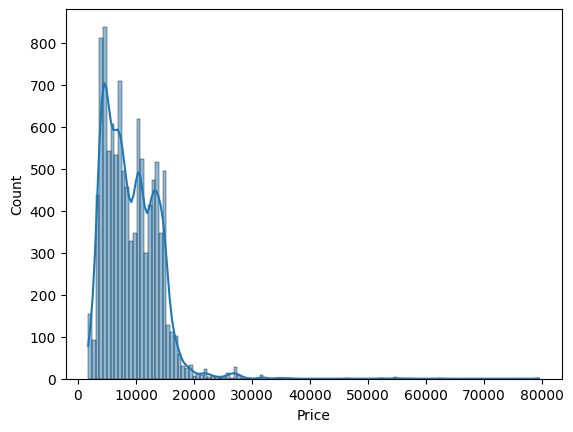

In [ ]:
import seaborn as sns
sns.histplot(data = df['Price'], kde = True)

* Filter out data where no of stops is 1 and price is more than 2000 Rs
* Filter out data where Source is Bangalore and Airline is Indigo
* Filter out Data where Additional Info is no info and price is more than 3000 Rs

In [ ]:
df[(df['Source'] == 'Banglore') & (df['Airline'] ==  'IndiGo')].count()

,0
Airline,523
Date_of_Journey,523
Source,523
Destination,523
Route,523
Dep_Time,523
Arrival_Time,523
Duration,523
Total_Stops,523
Additional_Info,523


In [ ]:
df[(df['Total_Stops'] == '1 stop') & (df['Price'] > 2000)].count()

,0
Airline,5625
Date_of_Journey,5625
Source,5625
Destination,5625
Route,5625
Dep_Time,5625
Arrival_Time,5625
Duration,5625
Total_Stops,5625
Additional_Info,5625


**Answers:** 523 IndiGo flights depart from Bangalore. 5,625 flights have exactly 1 stop and cost more than ₹2,000.

In [ ]:
df['Source'].unique()

array(['Banglore', 'Kolkata', 'Delhi', 'Chennai', 'Mumbai'], dtype=object)

In [ ]:
df['Source'].value_counts()

,count
Source,
Delhi,4536
Kolkata,2871
Banglore,2197
Mumbai,697
Chennai,381


**Insight:** Delhi is the busiest departure city (4,536 flights), more than double Bangalore's volume.

## 5. Column-wise Cleaning & Feature Engineering

In [ ]:
df['Airline'].unique()

array(['IndiGo', 'Air India', 'Jet Airways', 'SpiceJet',
       'Multiple carriers', 'GoAir', 'Vistara', 'Air Asia',
       'Vistara Premium economy', 'Jet Airways Business',
       'Multiple carriers Premium economy', 'Trujet'], dtype=object)

In [ ]:
df['Airline'].value_counts()

,count
Airline,
Jet Airways,3849
IndiGo,2053
Air India,1751
Multiple carriers,1196
SpiceJet,818
Vistara,479
Air Asia,319
GoAir,194
Multiple carriers Premium economy,13


**Note:** `Airline` contains near-duplicate categories worth being aware of downstream (`Jet Airways` vs `Jet Airways Business`, `Multiple carriers` vs `Multiple carriers Premium economy`) — these are kept separate below since they represent genuinely different fare classes, not data errors.

### 5.1 Date of Journey

**Extracting the day of journey — two approaches, compared:**

**Method 1 — loop-based:** simple to read, but iterates row by row in plain Python, which is slower on large datasets.

In [ ]:
day = []

for i in df['Date_of_Journey']:
  day.append(i.split('/')[0])

print(day)

['24', '1', '9', '12', '01', '24', '12', '01', '12', '27', '1', '18', '24', '9', '24', '3', '15', '12', '12', '27', '6', '21', '3', '1', '6', '9', '1', '15', '18', '15', '18', '1', '6', '15', '18', '27', '21', '18', '06', '3', '21', '15', '18', '6', '21', '24', '27', '3', '15', '27', '9', '1', '24', '18', '3', '24', '01', '6', '6', '6', '6', '3', '3', '15', '24', '24', '24', '6', '21', '12', '1', '09', '24', '24', '21', '09', '3', '3', '15', '21', '9', '24', '6', '27', '18', '06', '24', '6', '1', '24', '27', '6', '12', '6', '21', '21', '15', '3', '18', '12', '15', '9', '24', '12', '1', '18', '27', '27', '9', '24', '18', '12', '12', '6', '27', '18', '6', '3', '12', '9', '9', '3', '6', '1', '12', '21', '12', '6', '24', '3', '21', '15', '12', '15', '21', '18', '6', '27', '24', '3', '9', '6', '15', '9', '21', '21', '3', '3', '24', '9', '3', '21', '27', '12', '24', '9', '27', '03', '12', '6', '1', '24', '9', '9', '12', '27', '3', '21', '27', '27', '3', '18', '9', '27', '6', '12', '3', '21',

**Method 2 — vectorized (preferred):** using `.str.split()` operates on the whole column at once — faster and more idiomatic pandas. This is the version used going forward, and also extracts `MONTH` and `YEAR` in the same step.

In [ ]:
df['DAY'] = df['Date_of_Journey'].str.split('/').str[0].str.strip().astype(int)
df['MONTH'] = df['Date_of_Journey'].str.split('/').str[1].str.strip().astype(int)
df['YEAR'] = df['Date_of_Journey'].str.split('/').str[2].str.strip().astype(int)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10682 entries, 0 to 10682
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Airline          10682 non-null  object
 1   Date_of_Journey  10682 non-null  object
 2   Source           10682 non-null  object
 3   Destination      10682 non-null  object
 4   Route            10682 non-null  object
 5   Dep_Time         10682 non-null  object
 6   Arrival_Time     10682 non-null  object
 7   Duration         10682 non-null  object
 8   Total_Stops      10682 non-null  object
 9   Additional_Info  10682 non-null  object
 10  Price            10682 non-null  int64 
 11  DAY              10682 non-null  int64 
 12  MONTH            10682 non-null  int64 
 13  YEAR             10682 non-null  int64 
dtypes: int64(4), object(10)
memory usage: 1.5+ MB


In [ ]:
del df['Date_of_Journey']

### 5.2 Departure & Arrival Times

In [ ]:
df['DEP_HRS'] = df['Dep_Time'].str.split(':').str[0].str.strip().astype(int)
df['DEP_MIN'] = df['Dep_Time'].str.split(':').str[1].str.strip().astype(int)

In [ ]:
del df['Route']
del df['Dep_Time']

In [ ]:
df['ARRIVAL_HRS'] = df['Arrival_Time'].str.split(':').str[0].str.strip().astype(int)
df['ARRIVAL_MIN'] = df['Arrival_Time'].str.split(':').str[1].str.split().str[0].astype(int)

In [ ]:
del df['Arrival_Time']

### 5.3 Duration

In [ ]:
df['Duration'].value_counts()

,count
Duration,
2h 50m,550
1h 30m,386
2h 55m,337
2h 45m,337
2h 35m,329
...,...
37h 10m,1
32h 20m,1
40h 20m,1


**Note:** one row has a malformed `Duration` of `'5m'` (likely a scraping error) — dropped rather than parsed.

In [ ]:
df = df[df['Duration'] != '5m']

In [ ]:
df['HRS'] = df['Duration'].str.split().str[0].str.split('h').str[0].astype(int)
df['MIN'] = df['Duration'].str.split().str[1].str.split('m').str[0].fillna(0).astype(int)

/tmp/ipython-input-1429748948.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['HRS'] = df['Duration'].str.split().str[0].str.split('h').str[0].astype(int)
/tmp/ipython-input-1429748948.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['MIN'] = df['Duration'].str.split().str[1].str.split('m').str[0].fillna(0).astype(int)


> ⚠️ *Pandas raises a `SettingWithCopyWarning` on this line and the next — the result is still correct here, but it's worth adding `.copy()` right after the `df[df['Duration'] != '5m']` filter in the previous step to silence it and avoid ambiguity in future edits.*

In [ ]:
del df['Duration']

In [ ]:
df['Duration_in_mins'] = df['HRS']*60 + df['MIN']

/tmp/ipython-input-694932758.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Duration_in_mins'] = df['HRS']*60 + df['MIN']


In [ ]:
del df['HRS']
del df['MIN']

In [ ]:
df.head(5)

,Airline,Source,Destination,Total_Stops,Additional_Info,Price,DAY,MONTH,YEAR,DEP_HRS,DEP_MIN,ARRIVAL_HRS,ARRIVAL_MIN,Duration_in_mins
0,IndiGo,Banglore,New Delhi,non-stop,No info,3897,24,3,2019,22,20,1,10,170
1,Air India,Kolkata,Banglore,2 stops,No info,7662,1,5,2019,5,50,13,15,445
2,Jet Airways,Delhi,Cochin,2 stops,No info,13882,9,6,2019,9,25,4,25,1140
3,IndiGo,Kolkata,Banglore,1 stop,No info,6218,12,5,2019,18,5,23,30,325
4,IndiGo,Banglore,New Delhi,1 stop,No info,13302,1,3,2019,16,50,21,35,285


**Engineered columns:** `DAY`, `MONTH`, `YEAR` (from journey date), `DEP_HRS`/`DEP_MIN`, `ARRIVAL_HRS`/`ARRIVAL_MIN`, and `Duration_in_mins` — all parsed from raw text into numeric fields. Dataset is now ready for KPI analysis.

## 6. Key Performance Indicators

In [ ]:
'''
KPI's

1) Average Ticket Price by Airline
2) Average Ticket Price by Route (Source → Destination)
3) Average Price by Number of Stops
4) Flight Volume by Airline
5) Flight Volume by Source Airport
6) Monthly Price Trend
7) Average Departure Hour by Airline
'''

### KPI 1 — Average Ticket Price by Airline

In [ ]:
avg_price_by_airline = df.groupby('Airline')['Price'].mean().round(2).reset_index()
print(avg_price_by_airline)

                              Airline     Price
0                            Air Asia   5590.26
1                           Air India   9611.21
2                               GoAir   5861.06
3                              IndiGo   5673.68
4                         Jet Airways  11643.92
5                Jet Airways Business  58358.67
6                   Multiple carriers  10902.68
7   Multiple carriers Premium economy  11418.85
8                            SpiceJet   4338.28
9                              Trujet   4140.00
10                            Vistara   7796.35
11            Vistara Premium economy   8962.33


<Axes: xlabel='Airline'>

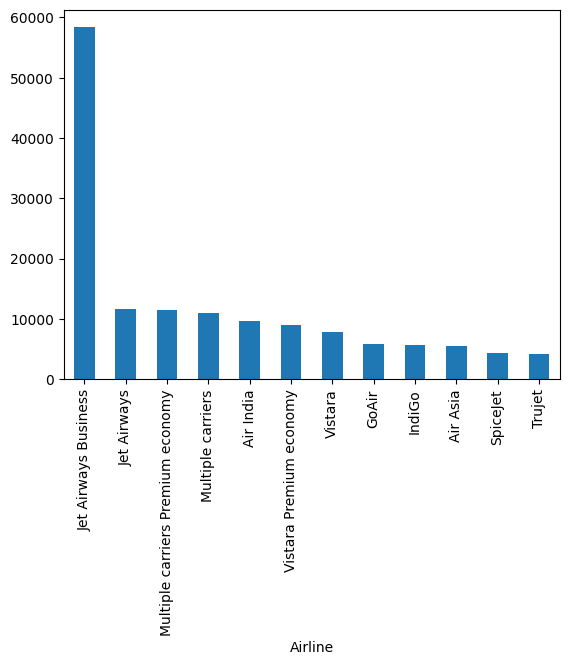

In [ ]:
df.groupby('Airline')['Price'].mean().sort_values(ascending=False).plot(kind = 'bar')

**Insight:** `Jet Airways Business` is the clear outlier at **~₹58,359** average — a business-class fare class, not a data error. Among standard economy airlines, `Air Asia` (~₹5,590) and `IndiGo` (~₹5,674) are cheapest, `Jet Airways` (~₹11,644) and `Multiple carriers` (~₹10,903) are priciest.

### KPI 2 — Average Ticket Price by Route

In [ ]:
Average_Ticket_Price_by_Route = df.groupby(['Source','Destination'])['Price'].mean()
print(Average_Ticket_Price_by_Route)

Source    Destination
Banglore  Delhi           5143.918577
          New Delhi      11917.716738
Chennai   Kolkata         4789.892388
Delhi     Cochin         10539.439057
Kolkata   Banglore        9158.389411
Mumbai    Hyderabad       5059.708752
Name: Price, dtype: float64


<Axes: xlabel='Source,Destination'>

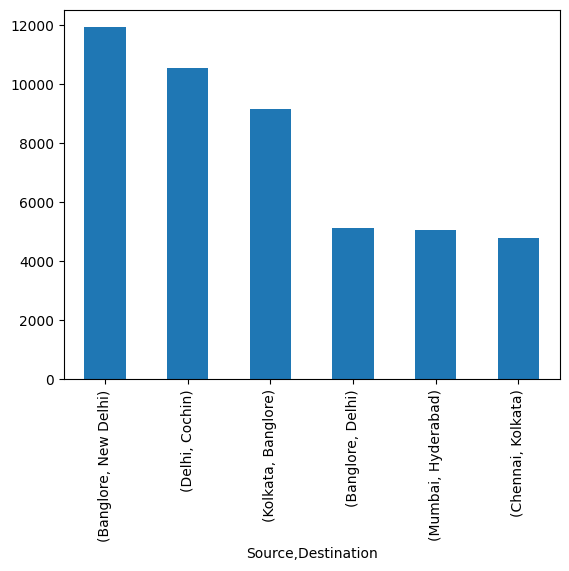

In [ ]:
df.groupby(['Source','Destination'])['Price'].mean().sort_values(ascending=False).plot(kind = 'bar')

**Insight:** Bangalore → New Delhi is the most expensive route (~₹11,918), while Chennai → Kolkata is the cheapest (~₹4,790) — over a 2x difference between the priciest and cheapest routes.

### KPI 3 — Average Price by Number of Stops

In [ ]:
avg_price_by_no_of_stops = df.groupby('Total_Stops')['Price'].mean()
print(avg_price_by_no_of_stops)

Total_Stops
1 stop      10594.123556
2 stops     12715.807895
3 stops     13112.000000
4 stops     17686.000000
non-stop     5024.900315
Name: Price, dtype: float64


**Insight:** Price rises steadily and consistently with each additional stop — from ~₹5,025 for non-stop flights to ~₹17,686 for 4-stop flights, roughly a 3.5x increase.

### KPI 4 — Flight Volume by Airline

In [ ]:
flight_volume = df['Airline'].value_counts()
print(flight_volume)

Airline
Jet Airways                          3849
IndiGo                               2053
Air India                            1752
Multiple carriers                    1196
SpiceJet                              818
Vistara                               479
Air Asia                              319
GoAir                                 194
Multiple carriers Premium economy      13
Jet Airways Business                    6
Vistara Premium economy                 3
Trujet                                  1
Name: count, dtype: int64


**Insight:** `Jet Airways` dominates volume with 3,849 flights (~36% of the dataset) — more than IndiGo and Air India combined.

### KPI 5 — Flight Volume by Source Airport

In [ ]:
Flight_Volume_by_Source_Airport = df.groupby('Source').size().reset_index(name='Total_Flights')
print(Flight_Volume_by_Source_Airport)

     Source  Total_Flights
0  Banglore           2197
1   Chennai            381
2     Delhi           4537
3   Kolkata           2871
4    Mumbai            697


**Insight:** Delhi is the busiest source airport (4,537 flights, ~42% of all listings).

### KPI 6 — Monthly Price Trend

In [ ]:
Monthly_price_Trend= df.groupby('MONTH')['Price'].mean().reset_index()
print(Monthly_price_Trend)

   MONTH         Price
0      3  10673.205580
1      4   5770.847081
2      5   9127.247548
3      6   8828.796134


**Insight:** March is the most expensive month to fly (~₹10,673 average), April the cheapest (~₹5,771) — note the dataset only covers March–June, so this isn't a full-year seasonal trend.

### KPI 7 — Average Departure Hour by Airline

In [ ]:
Average_Departure_Hour_by_Airline= df.groupby('Airline')['DEP_HRS'].mean().round(1).reset_index()
print(Average_Departure_Hour_by_Airline)

                              Airline  DEP_HRS
0                            Air Asia     14.0
1                           Air India     12.3
2                               GoAir     11.8
3                              IndiGo     12.2
4                         Jet Airways     13.4
5                Jet Airways Business     10.7
6                   Multiple carriers     10.1
7   Multiple carriers Premium economy      7.8
8                            SpiceJet     12.3
9                              Trujet     13.0
10                            Vistara     13.1
11            Vistara Premium economy     11.3


**Insight:** `Air Asia` departs latest on average (~2:00 PM), while `Multiple carriers` departs earliest (~10:06 AM) — a meaningful spread across airlines' typical scheduling.

## 7. Key Takeaways- **Fare class matters more than airline:** `Jet Airways Business` prices are ~5x standard economy — segment by fare class, not just airline name, in any pricing model.- **Stops are a strong price driver:** price increases roughly linearly with each additional stop (₹5,025 → ₹17,686 across non-stop to 4 stops).- **Route asymmetry:** a 2x+ price gap exists between the cheapest and priciest routes in the dataset.- **Volume is concentrated:** Jet Airways and Delhi account for a disproportionate share of both flights and departures.- **Limited seasonal window:** the dataset only spans March–June, so monthly trends shouldn't be read as full-year seasonality.## 8. Possible Next Steps- Build a simple price-prediction model (regression) using stops, duration, airline, and route as features.- Separate `Jet Airways Business` / `Multiple carriers Premium economy` into an explicit `fare_class` column instead of leaving it embedded in `Airline`.- Extend the KPI analysis into an interactive Power BI or HTML dashboard.